# Пункт f

### Константы

In [22]:
import numpy as np
import matplotlib.pyplot as plt

In [23]:
n = 100
theta = 10
beta = 0.95
U_0_025 = -1.96
U_0_975 = 1.96

#для bootstrap
N_non_param = 10000
N_param = 1000000


### Создание выборки
![alt text](sample_generation.jpeg)

In [24]:
def sample_from_distribution(size: int, theta_ = theta):
    """для моделирования случайной величины разыгрываем равномерно
    распределённую сл.вел. ~ R(0,1);
    Выражаем x из значения функции распределения"""
    function_values_arr = np.random.uniform(0, 1, size)
    sample = theta_ * (function_values_arr + 1)
    return sample

sample = sample_from_distribution(n)
print(sample)

[19.74133465 10.34476831 15.42124071 19.56525989 15.52026824 11.69681869
 15.87236012 17.86666817 14.40861811 14.25410083 11.63706098 19.87715619
 11.25526329 19.97674742 12.38884879 13.72558984 11.69250559 18.58752833
 15.3148857  10.76337621 10.08929008 15.43076989 16.08504966 10.89589052
 14.76293181 14.71740048 11.8535439  18.32467661 19.64168123 11.23064632
 12.02025482 10.44377744 18.69005121 13.24985004 11.60466786 11.78988968
 12.21531451 14.88801204 10.84536895 15.94440396 17.78374135 16.52916821
 10.76749375 18.72053144 11.69027974 13.80875493 19.15784541 10.04711448
 15.12181531 12.34908151 14.12817841 16.76014901 14.69385864 18.65494492
 18.08577782 11.48196479 15.27007603 18.7445824  11.59208927 17.90448997
 16.5781448  14.77034754 12.1697891  17.63167885 12.65599629 11.49986616
 16.93519144 10.9586086  13.38170062 18.71793477 17.09239986 16.57825061
 14.23736432 18.35003819 12.66451549 15.20224053 16.44175947 15.71694871
 15.28797247 15.55298854 13.85487163 15.92105848 10

### Точный доверительный интервал


In [25]:
max_elem = sample.max()

exact_interval_left = max_elem / (1 + ((1 + beta)/2)**(1/n))
exact_interval_right = max_elem / (1 + ((1 - beta)/2)**(1/n))

l_exact = exact_interval_right - exact_interval_left

print(f"Левая граница: {exact_interval_left}")
print(f"Правая граница: {exact_interval_right}")
print(f"Длина точного доверительного интервала: {l_exact}")


Левая граница: 9.989638127770903
Правая граница: 10.17258235338967
Длина точного доверительного интервала: 0.18294422561876722


### Асимтотический доверительный интервал

In [26]:
alpha_1 = np.mean(sample)
alpha_2 = np.sum(sample**2) / n

theta_est = 2 * alpha_1 / 3
asymptotic_interval_left = theta_est - (U_0_975*2*np.sqrt(alpha_2-alpha_1**2))/(3*np.sqrt(n))
asymptotic_interval_right = theta_est - (U_0_025*2*np.sqrt(alpha_2-alpha_1**2))/(3*np.sqrt(n))

l_asymptotic = asymptotic_interval_right - asymptotic_interval_left

print(f"Левая граница: {asymptotic_interval_left}")
print(f"Правая граница: {asymptotic_interval_right}")
print(f"Длина асимтотического доверительного интервала: {l_asymptotic}")

Левая граница: 9.401634810217823
Правая граница: 10.166026611675994
Длина асимтотического доверительного интервала: 0.7643918014581708


# Пункт g

### Непараметрический bootstrap (ОММ)

In [27]:
def non_prm_bootstrap_deltas_OMM(sample: np.ndarray, n: int) -> np.ndarray:
    """аргумент n - количество подвыборок"""
    deltas = np.zeros(n)
    sample_theta = (2/3)*np.mean(sample)
    for i in range(n):
        bootstrap_sample = np.random.choice(
            sample,
            size = sample.size,
            replace=True  #c повторениями элементов
        )
        bootstrap_theta = (2/3)*np.mean(bootstrap_sample)
        deltas[i] = sample_theta - bootstrap_theta

    return deltas

variation_series_n_p_b_omm = np.sort(non_prm_bootstrap_deltas_OMM(sample, N_non_param))
k1 = int((1-beta) * N_non_param/2)
k2 = int((1+beta) * N_non_param/2)

sample_theta = (2/3) * np.mean(sample)

n_param_bootstrap_interval_left_omm = sample_theta - variation_series_n_p_b_omm[k2]
n_param_bootstrap_interval_right_omm = sample_theta - variation_series_n_p_b_omm[k1]

l_n_param_bootstrap_omm = n_param_bootstrap_interval_right_omm - n_param_bootstrap_interval_left_omm


print(f"Левая граница: {n_param_bootstrap_interval_left_omm}")
print(f"Правая граница: {n_param_bootstrap_interval_right_omm}")
print(f"Длина непараметрического (ОММ) доверительного интервала: {l_n_param_bootstrap_omm}")

Левая граница: 9.396461910961932
Правая граница: 10.16471335644455
Длина непараметрического (ОММ) доверительного интервала: 0.7682514454826173


### Непараметрический bootsrap (ОМП)

In [28]:
def non_prm_bootstrap_deltas_OMP(sample: np.ndarray, n: int) -> np.ndarray:
    """аргумент n - количество подвыборок"""
    deltas = np.zeros(n)
    sample_theta = ((n+1)/(2*n+1)) * sample.max()
    for i in range(n):
        bootstrap_sample = np.random.choice(
            sample,
            size = sample.size,
            replace=True  #c повторениями элементов
        )
        bootstrap_theta = ((n+1)/(2*n+1)) * bootstrap_sample.max()
        deltas[i] = sample_theta - bootstrap_theta

    return deltas

variation_series_n_p_b_omp = np.sort(non_prm_bootstrap_deltas_OMP(sample, N_non_param))
k1 = int((1-beta) * N_non_param/2)
k2 = int((1+beta) * N_non_param/2)

sample_theta = ((n+1)/(2*n+1)) * sample.max()

n_param_bootstrap_interval_left_omp = sample_theta - variation_series_n_p_b_omp[k2]
n_param_bootstrap_interval_right_omp = sample_theta - variation_series_n_p_b_omp[k1]

l_n_param_bootstrap_omp = n_param_bootstrap_interval_right_omp - n_param_bootstrap_interval_left_omp


print(f"Левая граница: {n_param_bootstrap_interval_left_omp}")
print(f"Правая граница: {n_param_bootstrap_interval_right_omp}")
print(f"Длина непараметрического (ОМП) доверительного интервала: {l_n_param_bootstrap_omp}")

Левая граница: 9.900764627878992
Правая граница: 10.038067110677448
Длина непараметрического (ОМП) доверительного интервала: 0.13730248279845547


### Параметрический bootstrap (ОММ)

In [34]:
def generate_prm_bootsrap_sample_omm(mean_element):
    theta_estmation = (2/3) * mean_element
    return sample_from_distribution(n, theta_estmation)

def parametric_bootstrap_deltas_OMM(sample: np.ndarray, N: int) -> np.ndarray:
    """аргумент n - количество подвыборок"""
    deltas = np.zeros(N)
    sample_theta = (2/3) * np.mean(sample)
    for i in range(N):
        bootstrap_sample = generate_prm_bootsrap_sample_omm(np.mean(sample))
        bootstrap_theta = (2/3) * np.mean(bootstrap_sample)
        deltas[i] = sample_theta - bootstrap_theta

    return deltas

variation_series_p_b_omm = np.sort(parametric_bootstrap_deltas_OMM(sample, N_param))
k1 = int((1-beta) * N_param/2)
k2 = int((1+beta) * N_param/2)

sample_theta = (2/3) * np.mean(sample)

param_bootstrap_interval_left_omm = sample_theta - variation_series_p_b_omm[k2]
param_bootstrap_interval_right_omm = sample_theta - variation_series_p_b_omm[k1]

l_param_bootstrap_omm = param_bootstrap_interval_right_omm - param_bootstrap_interval_left_omm


print(f"Левая граница: {param_bootstrap_interval_left_omm}")
print(f"Правая граница: {param_bootstrap_interval_right_omm}")
print(f"Длина параметрического (ОММ) доверительного интервала: {l_param_bootstrap_omm}")

Левая граница: 9.415251403875274
Правая граница: 10.152641609578737
Длина параметрического (ОММ) доверительного интервала: 0.7373902057034627


### Параметрический bootstrap (ОМП)

In [33]:
def generate_prm_bootsrap_sample_omp(max_elem):
    theta_estmation = (n+1)* max_elem / (2*n + 1)
    return sample_from_distribution(n, theta_estmation)

def parametric_bootstrap_deltas_OMP(sample: np.ndarray, N: int) -> np.ndarray:
    """аргумент n - количество подвыборок"""
    deltas = np.zeros(N)
    sample_theta = sample.max() * (n + 1) / (2 * n + 1)
    for i in range(N):
        bootstrap_sample = generate_prm_bootsrap_sample_omp(sample.max())
        bootstrap_theta = bootstrap_sample.max() * (n + 1) / (2 * n + 1)
        deltas[i] = sample_theta - bootstrap_theta

    return deltas

variation_series_p_b_omp = np.sort(parametric_bootstrap_deltas_OMP(sample, N_param))
k1 = int((1-beta) * N_param/2)
k2 = int((1+beta) * N_param/2)

sample_theta = sample.max() * (n + 1) / (2 * n + 1)

param_bootstrap_interval_left_omp = sample_theta - variation_series_p_b_omp[k2]
param_bootstrap_interval_right_omp = sample_theta - variation_series_p_b_omp[k1]

l_param_bootstrap_omp = param_bootstrap_interval_right_omp - param_bootstrap_interval_left_omp


print(f"Левая граница: {param_bootstrap_interval_left_omp}")
print(f"Правая граница: {param_bootstrap_interval_right_omp}")
print(f"Длина параметрического (ОМП) доверительного интервала: {l_param_bootstrap_omp}")

Левая граница: 9.905316032701515
Правая граница: 10.086727072624777
Длина параметрического (ОМП) доверительного интервала: 0.1814110399232618


# Пункт h

### Сравнение доверительных интервалов

C:\Users\hp\AppData\Local\Temp\ipykernel_19048\1410439495.py:32: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('|').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x1, i, s=80, color=colors[i], edgecolor='black',
C:\Users\hp\AppData\Local\Temp\ipykernel_19048\1410439495.py:34: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('|').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x2, i, s=80, color=colors[i], edgecolor='black',


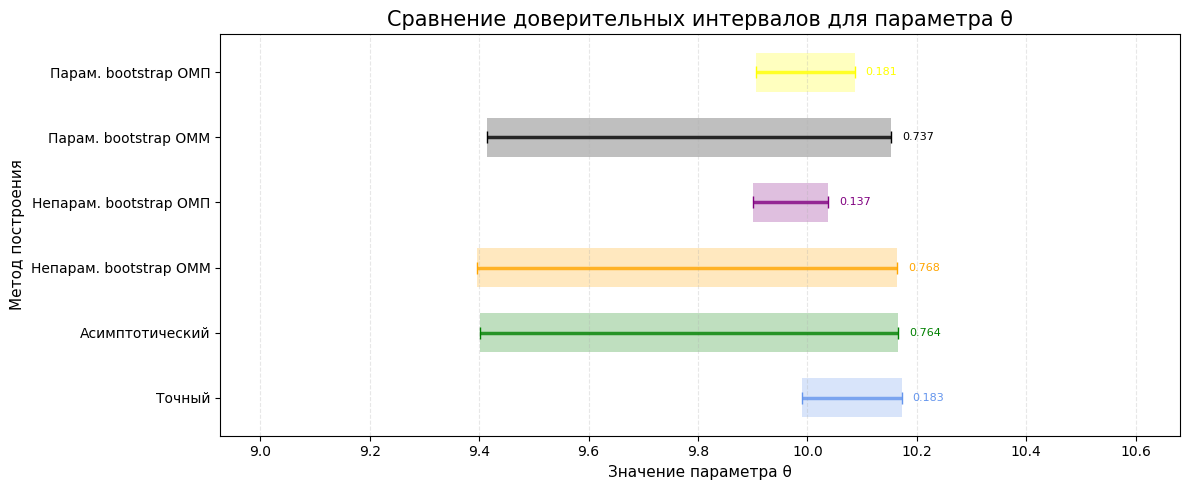

In [36]:
segments = [
    [exact_interval_left, exact_interval_right],
    [asymptotic_interval_left, asymptotic_interval_right],
    [n_param_bootstrap_interval_left_omm, n_param_bootstrap_interval_right_omm],
    [n_param_bootstrap_interval_left_omp, n_param_bootstrap_interval_right_omp],
    [param_bootstrap_interval_left_omm, param_bootstrap_interval_right_omm],
    [param_bootstrap_interval_left_omp, param_bootstrap_interval_right_omp],
]

names = [
    "Точный",
    "Асимптотический",
    "Непарам. bootstrap OMM",
    "Непарам. bootstrap OMП",
    "Парам. bootstrap ОММ",
    "Парам. bootstrap ОМП"
]
colors = ["cornflowerblue", "green", "orange", "purple", "black", "yellow"]

fig, ax = plt.subplots(figsize=(12, 5))

all_points = [point for interval in segments for point in interval]
x_min = min(all_points) - 0.05 * abs(min(all_points)) if min(all_points) > 0 else min(all_points) - 0.1
x_max = max(all_points) + 0.05 * abs(max(all_points)) if max(all_points) > 0 else max(all_points) + 0.1

for i, (x1, x2) in enumerate(segments):
    width = x2 - x1
    ax.barh(y=i, width=width, left=x1, height=0.6, 
            alpha=0.25, color=colors[i], edgecolor='none')
    ax.hlines(y=i, xmin=x1, xmax=x2, linewidth=2.5, color=colors[i], alpha=0.8)

    ax.scatter(x1, i, s=80, color=colors[i], edgecolor='black', 
               linewidth=1, zorder=5, marker='|')
    ax.scatter(x2, i, s=80, color=colors[i], edgecolor='black', 
               linewidth=1, zorder=5, marker='|')
    ax.text(x2 + 0.02, i, f'{width:.3f}', 
            ha='left', va='center', fontsize=8, color=colors[i])

ax.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

ax.set_yticks(range(len(segments)))
ax.set_yticklabels(names, fontsize=10)
ax.set_xlim(x_min, x_max)
ax.set_xlabel('Значение параметра θ', fontsize=11)
ax.set_ylabel('Метод построения', fontsize=11)
ax.set_title('Сравнение доверительных интервалов для параметра θ', fontsize=15)
ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()